In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache("../cache")

session = fastf1.get_session(2024, "Monaco", "Q")
session.load()

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']


In [2]:
session.results.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [3]:
teams = session.results[
    ["TeamName", "Abbreviation", "Q3"]
].dropna()

teams.head()

,TeamName,Abbreviation,Q3
16,Ferrari,LEC,0 days 00:01:10.270000
81,McLaren,PIA,0 days 00:01:10.424000
55,Ferrari,SAI,0 days 00:01:10.518000
4,McLaren,NOR,0 days 00:01:10.542000
63,Mercedes,RUS,0 days 00:01:10.543000


In [4]:
teams["Q3_seconds"] = teams["Q3"].dt.total_seconds()

teams.head()

,TeamName,Abbreviation,Q3,Q3_seconds
16,Ferrari,LEC,0 days 00:01:10.270000,70.270
81,McLaren,PIA,0 days 00:01:10.424000,70.424
55,Ferrari,SAI,0 days 00:01:10.518000,70.518
4,McLaren,NOR,0 days 00:01:10.542000,70.542
63,Mercedes,RUS,0 days 00:01:10.543000,70.543


In [5]:
team_avg = (
    teams.groupby("TeamName")["Q3_seconds"]
    .mean()
    .sort_values()
)

team_avg

TeamName
Ferrari            70.394
McLaren            70.483
Red Bull Racing    70.567
Mercedes           70.582
RB                 70.858
Williams           70.948
Alpine             71.311
Name: Q3_seconds, dtype: float64

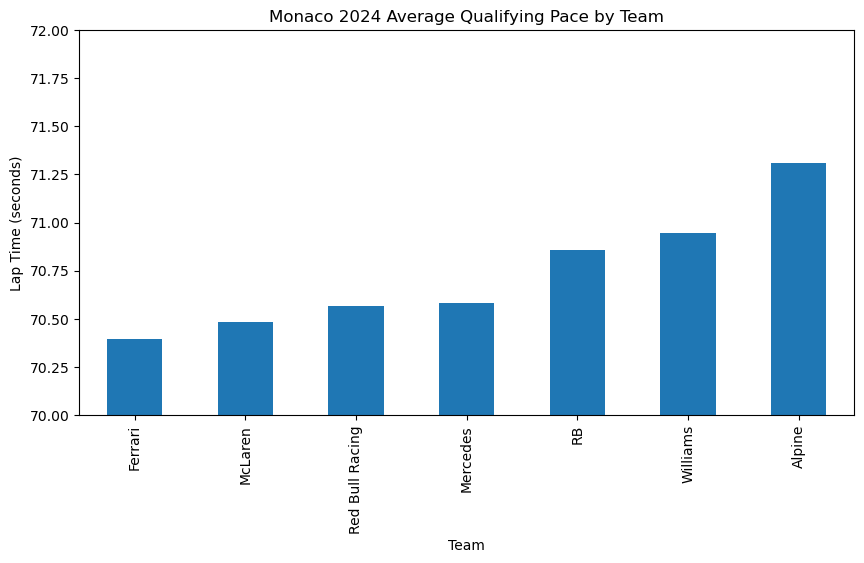

In [7]:
plt.figure(figsize=(10,5))

team_avg.plot(kind="bar")

plt.title("Monaco 2024 Average Qualifying Pace by Team")
plt.ylabel("Lap Time (seconds)")
plt.xlabel("Team")

plt.ylim(70,72)

plt.show()

# Conclusion

Ferrari, McLaren, Red Bull, and Mercedes were among the fastest
teams during Monaco 2024 qualifying.

Average qualifying pace provides a useful way to compare team
performance rather than focusing on a single driver.